# Configuration

This notebook will describe the various configuration files, including their roles in the framework, what is defined within them, which configs come pre-installed, and how to write your own.

Each of these config objects is based on a base `Config` class, which can be interacted with much like a dictionary.  Additionally, each config class has a `default` instance, and the `config` module comes with a dictionary of pre-set configuration objects.

## Units

First, let's discuss the way that units are handled in this framework.  Internally, values are stored without units, with the implied units being defined in `units.py`:

|Quantity | unit | symbol|
|---------|------|-------|
|mass | kilogram | kg|
|length | centimeter | cm |
|time | microsecond | $\mathrm{\mu}$ s |
|charge | positron charge | e |
|temperature | Kelvin | K |
|energy | Mega electron-volt | MeV |
|amount of substance | mole | mol |
|luminous intensity | candela | cd |
|angle | radian | |
|solid angle | sterradian | |

`units.py` supplies a number of conversion factors for converting into this coordinate system.  For example, 

In [1]:
from gampixpy import units

print (1*units.ms) # 1 millisecond == 1000 microseconds
print (1*units.C) # 1 Coulomb == 6.242e18 e

1000.0
6.242e+18


`units.py` also provides a `unit_parser` function, which converts a string of units to the appropriate conversion factor.  This string should be formatted as a simple expression delimitted by `*` or `/` characters, to indicate positive and negative powers.  Unit expressions with powers other than +/-1 should simply use repeated instances of the unit.  For example,

In [2]:
# cm^2/(us*MeV)
# the exponent of cm should be expanded:
print(units.unit_parser('cm*cm/us/MeV'))

# An expression for an alternative unit 
# which might describe the same quantity:
print(units.unit_parser('nm*nm/ms/GeV'))

1.0
1e-20


With these tools, values are parsed from a static configuration file (YAML format) from an (almost) arbitrary specification of the relevant quantities.

## Detector Configuration

The detector configuration defines some basic geometry of the TPC volume(s).  The details needed to specify the volume are:

- Anode center: (x, y, z) coordinates (in the external coordinate system) of the center of the anode plane.  This defines the origin of the TPC coordinate system.
- Anode span: the extent of the anode (width and height)
- Anode vertical: A vector defining the "vertical" direction of the anode (corresponding to the "height" defined above)
- drift axis: A vector defining the drift direction (pointing from anode to cathode)
- depth: the extent of the TPC in the drift direction (the distance from anode to cathode)

For example, let's look at the YAML file describing the default detector config:

In [3]:
!cat ../../gampixpy/detector_config/default.yaml

drift_volumes:
  volume_0:
    anode_center:
      x:
        value: 0
        unit: cm
      y:
        value: 0
        unit: cm
      z:
        value: 0
        unit: cm
    anode_span:
      width:
        value: 2000
        unit: cm
      height:
        value: 2000
        unit: cm
    anode_vertical:
      x: 0
      y: 1
      z: 0
    drift_direction:
      x: 0
      y: 0
      z: 1
    depth:
      value: 1000
      unit: cm

You can see how the above quantities are defined and, where needed, unitful quantities are specified with both a `value` and `unit` field.

### Inferred Detector Parameters

From these specifications, a few more helpful details are constructed:

- Anode horizontal: A vector defining the "horizontal" direction of the anode (corresponding to the "width" defined above).  This is perpendicular to the above defined vertical vector and drift vector
- Anode corners: The points describing the corners of the rectangle describing the anode plane
- Cathode corners: The points describing the corners of the cathode
- Corners: a single tensor containing all corners (anode + cathode)
- Connectivity: A static boolean matrix describing which corners are connected by an edge of the TPC

In [4]:
from gampixpy import config

dc = config.default_detector_params
print (dc) # note that units are implied once the config file is loaded

{'drift_volumes': {'volume_0': {'anode_center': tensor([0., 0., 0.]), 'anode_span': {'width': 2000.0, 'height': 2000.0}, 'anode_vertical': tensor([0., 1., 0.]), 'drift_direction': {'x': 0, 'y': 0, 'z': 1}, 'depth': 1000.0, 'anode_horizontal': tensor([1., 0., 0.]), 'drift_axis': tensor([0., 0., 1.]), 'anode_corners': [tensor([-1000., -1000.,     0.]), tensor([-1000.,  1000.,     0.]), tensor([ 1000., -1000.,     0.]), tensor([1000., 1000.,    0.])], 'cathode_corners': [tensor([-1000., -1000.,  1000.]), tensor([-1000.,  1000.,  1000.]), tensor([ 1000., -1000.,  1000.]), tensor([1000., 1000., 1000.])], 'corners': tensor([[-1000., -1000.,     0.],
        [-1000.,  1000.,     0.],
        [ 1000., -1000.,     0.],
        [ 1000.,  1000.,     0.],
        [-1000., -1000.,  1000.],
        [-1000.,  1000.,  1000.],
        [ 1000., -1000.,  1000.],
        [ 1000.,  1000.,  1000.]]), 'connectivity': tensor([[False,  True,  True, False,  True, False, False, False],
        [ True, False, Fal

### Preset Detector Configs

These are the pre-defined detector geometries which come along with the framework.  If you have defined your own geometry and would like to have it added to the list of preset configurations, please let me know!

In [5]:
print(config.preset_detector_configs.keys())

# to get, e.g. the coherent 250 geometry, just use the key!
coh_dc = config.preset_detector_configs['coh_250']

dict_keys(['far_detector_vd', 'default', 'far_detector_v2', 'coh_250', 'far_detector'])


Lastly, let's visualize the geometry using the event display.  For now, we need to use a `null_track` to initialize the `EventDisplay` object.  Usually, we have some event data to also show

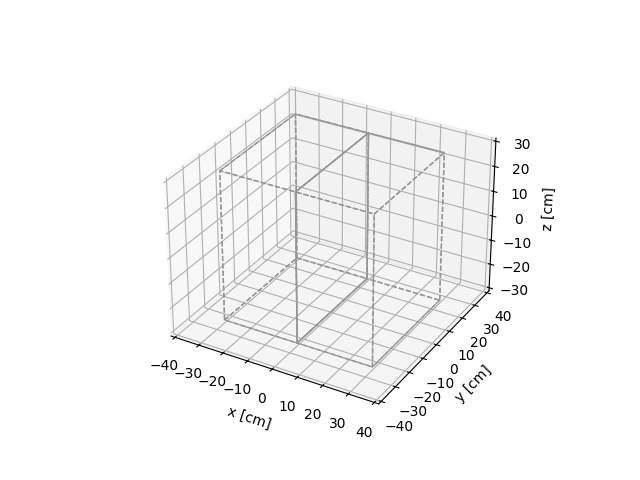

In [6]:
from gampixpy import plotting, tracks
%matplotlib widget

evd = plotting.EventDisplay(tracks.null_track)
evd.plot_drift_volumes(coh_dc)
evd.show()

## Physics Configuration

This set of parameters defines the physical properties of the detector material (LAr) and parameters pertaining to drift mechanics and charge yield.  These parameters very rarely need to be changed, and the default is usually fine.

The parameters defined in the YAML file are:
- material: some quantitative and qualitative descriptions of the material.  Includes nominal temperature, charge work function, density, etc.
- box model parameters: parameters of the modified box model used in recombination calculation
- birks model parameters: parameters of the Birk's model used in recombination calculation
- charge drift parameters: parameters of the charge mobility model used to calculate the nominal drift speed and diffusion constants for a particular value of electric field and temperature.  This sub-dictionary also specifies the drift field value and electron lifetime

In [7]:
!cat ../../gampixpy/physics_config/default.yaml

material:
  name: LAr
  temperature:
    value: 87
    unit: K
  long_name: "Liquid Argon"
  w:
    value: 2.36e-5
    unit: MeV # /ion pair
  density:
    value: 1.396
    unit: g/mL
  fano: 0.1160
  sigma_p: 0.0600

box_model:
  box_alpha: 0.93
  box_beta:
    value: 0.212
    unit: kV/cm*g/cm/cm/MeV # R. Acciarri et al JINST 8 (2013) P08005

birks_model:
  birks_ab: 0.806
  birks_kb:
    value: 0.052
    unit: kV/cm*g/cm/cm/MeV # Amoruso, et al NIM A 523 (2004) 275

charge_drift:
  mobility_parameter_a0: 551.6
  mobility_parameter_a1: 7158.3
  mobility_parameter_a2: 4440.43
  mobility_parameter_a3: 4.29
  mobility_parameter_a4: 43.63
  mobility_parameter_a5: 0.2053
  mobility_reference_T0: 89 # K
  mobility_parameter_b0: 0.0075 # eV
  mobility_parameter_b1: 742.9
  mobility_parameter_b2: 3269.6
  mobility_parameter_b3: 31678.2
  mobility_reference_T1:
    value: 87
    unit: K
  electron_lifetime:
    value: 10
    unit: ms
  drift_field:
    value: 0.5
    unit: kV/cm

### Inferred Physics Parameters

From these parameters, we invoke the actual models (defined in `recombination.py` and `mobility.py`) to calculate the explicit drift parameters:

- electron mobility
- drift energy
- diffusion longitudinal/transverse
- drift speed

In [8]:
pc = config.default_physics_params
print (pc)

{'material': {'name': 'LAr', 'temperature': 87, 'long_name': 'Liquid Argon', 'w': 2.36e-05, 'density': 0.0013959999999999999, 'fano': 0.116, 'sigma_p': 0.06}, 'box_model': {'box_alpha': 0.93, 'box_beta': 2.12e-07}, 'birks_model': {'birks_ab': 0.806, 'birks_kb': 5.1999999999999996e-08}, 'charge_drift': {'mobility_parameter_a0': 551.6, 'mobility_parameter_a1': 7158.3, 'mobility_parameter_a2': 4440.43, 'mobility_parameter_a3': 4.29, 'mobility_parameter_a4': 43.63, 'mobility_parameter_a5': 0.2053, 'mobility_reference_T0': 89, 'mobility_parameter_b0': 0.0075, 'mobility_parameter_b1': 742.9, 'mobility_parameter_b2': 3269.6, 'mobility_parameter_b3': 31678.2, 'mobility_reference_T1': 87, 'electron_lifetime': 10000.0, 'drift_field': 0.0005, 'electron_mobility': 320.22680490595025, 'drift_energy': 2.069477981671871e-08, 'diffusion_longitudinal': 6.627023218939979e-06, 'diffusion_ratio': 0.5005312849756938, 'diffusion_transverse': 1.323997803506287e-05, 'drift_speed': 0.16011340245297512}}


### Preset Physics Configs

So far, only the default set of physics parameters are provided.

In [9]:
print(config.preset_physics_configs.keys())

# to get, e.g. the default physics parameters, just use the key!
def_dc = config.preset_physics_configs['default']

dict_keys(['default'])


## Readout Configuration

This config file defines the details of the anode plane, e.g. pitches for coarse tiles, noise levels, thresholds, etc.  It also defines the kind of truth propagation the user desires

- truth tracking: can be enabled (`enabled: True`) or disabled (`enabled: False`), and can use labels `pdg`, `vertex`, or `segment` for tracking of particle type, vertex ID, or segment ID for each hit, respectively
- coarse tiles: specification of the coarse tile geometry.  The most relevant parameters here are the pitch (distance from center to center of neighboring coarse tiles), noise level, clock interval, threshold, and integration length
- pixels: specification of the pixel geometry.  The most relevant parameters here are the pitch (distance from center to center of neighboring pixels), noise level, clock interval, and threshold.  **Note that the pixel pitch should evenly divide the provided coarse tile pitch!**

In [10]:
!cat ../../gampixpy/readout_config/default.yaml

truth_tracking:
  enabled: True
  label: pdg

coarse_tiles:
  type: coarse_tiles
  pitch:
    value: 50
    unit: cm
  gap:
    value: 0.01
    unit: cm
  power_per_tile:
    value: 1.e-3
    unit: J/s
  noise:
    value: 50
    unit: e
  threshold_sigma: 5.0
  signal_fraction: 1
  clock_interval:
    value: 1.
    unit: us
  z_bin_width: 50
  integration_length: 1

pixels:
  type: pixels
  pitch:
    value: 10
    unit: cm
  power_per_pixel:
    value: 1.e-3
    unit: J/s
  noise:
    value: 50
    unit: e
  threshold_sigma: 4.0
  clock_interval:
    value: 1.
    unit: us
  z_bin_width: 10
  integration_length: 1


In [11]:
rc = config.default_readout_params
print (rc)

{'truth_tracking': {'enabled': True, 'label': 'pdg'}, 'coarse_tiles': {'type': 'coarse_tiles', 'pitch': 50.0, 'gap': 0.01, 'power_per_tile': 6242.0, 'noise': 50.0, 'threshold_sigma': 5.0, 'signal_fraction': 1, 'clock_interval': 1.0, 'z_bin_width': 50, 'integration_length': 1}, 'pixels': {'type': 'pixels', 'pitch': 10.0, 'power_per_pixel': 6242.0, 'noise': 50.0, 'threshold_sigma': 4.0, 'clock_interval': 1.0, 'z_bin_width': 10, 'integration_length': 1}}


### Preset Readout Configs

A few handy preset readout configs are shipped with the library.  One particularly handy readout is the `demo_large_pixels` config, which has some absurdly large tiles/pixels, which makes for good-looking demonstration plots and is helpful for debugging (larger and fewer pixels helps greatly with performance)

In [12]:
print(config.preset_readout_configs.keys())

# to get, e.g. the demo readout config, just use the key!
demo_rc = config.preset_readout_configs['demo_large_pixels']

dict_keys(['fine_pitch_500u', 'far_detector', 'GAMPixD_segment_tagging', 'GAMPixD_lowtrig_3mm_segment_tagging', 'rpix', 'superfine', 'GAMPixD_notruth', 'GAMPixD', 'demo_large_pixels', 'fine_pitch_4', 'fine_pitch_3', 'GAMPixD_vertex_tagging', 'rpix_high_noise', 'demo_large_pixels_gampix', 'default', 'fine_pitch_2', 'GAMPixD_lowtrig_segment_tagging'])
